## Investigation on free boundary

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from black_scholes.tree import BinomialTree
from neural_network.config import MarketParams
from heston.tree import HestonTreeFast

### Black-Scholes

In [2]:
S0 = 1.0
K = 1.0
T = 1.0
r = 0.05
sigma = 0.2

market_params = MarketParams(n_assets=1, S0=S0, K=K, T=T, r=r, sigma=sigma)

bt = BinomialTree(market_params, n_steps=100)

In [3]:
ts = np.linspace(0, T-1e-5, 100)
free_boundary = np.zeros_like(ts)

for i, t in enumerate(ts):
    # Find smallest S such that option value is greater than intrinsic value by binary search
    low = 0.0
    high = 2.0 * S0
    while high - low > 1e-5:
        mid = (low + high) / 2
        option_value = bt.predict(t, mid)
        intrinsic_value = max(0.0, K - mid)
        if option_value > intrinsic_value:
            high = mid
        else:
            low = mid
    free_boundary[i] = (low + high) / 2


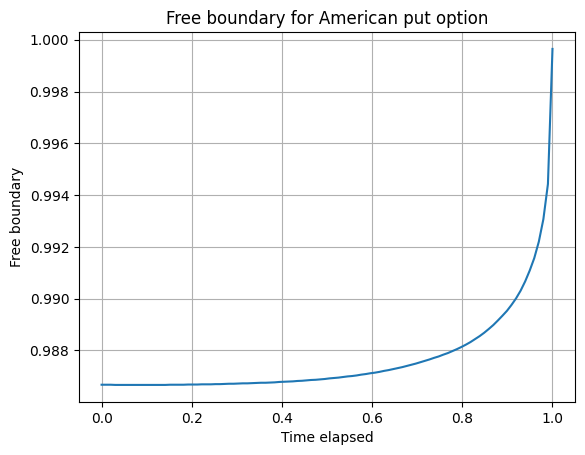

In [4]:
plt.plot(ts, free_boundary)
plt.xlabel('Time elapsed')
plt.ylabel('Free boundary')
plt.title('Free boundary for American put option')
plt.grid()
plt.show()

### Heston

In [5]:
S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

In [6]:
n = 100
mv = 6 * n
mz = 12 * n

ht = HestonTreeFast(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
ht.build_tree(0.01, 0.3, 0.5, 2, "put", "american")

In [7]:
Vs = np.array([0.01, 0.05, 0.1, 0.2])

free_boundary_h = np.zeros((4, 100))

for i, V in enumerate(Vs):
    for k in range(n):
        low = 0.0
        high = 2.0 * S0
        while high - low > 1e-5:
            mid = (low + high) / 2
            option_value = ht.price(V, mid, k)
            intrinsic_value = max(0.0, K - mid)
            if option_value > intrinsic_value:
                high = mid
            else:
                low = mid
        free_boundary_h[i, k] = (low + high) / 2


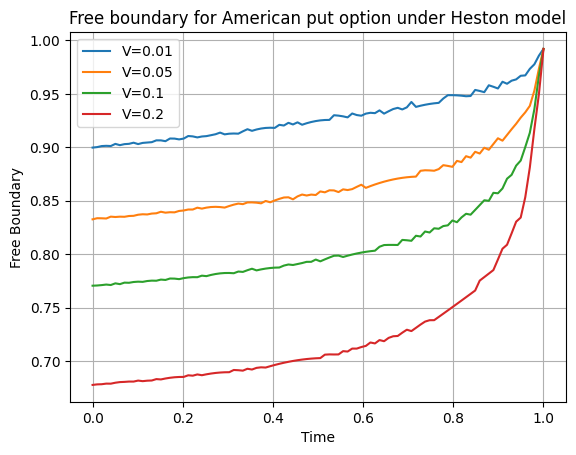

In [8]:
for i, V in enumerate(Vs):
    plt.plot(ts, free_boundary_h[i, :], label=f'V={V}')
plt.xlabel('Time')
plt.ylabel('Free Boundary')
plt.title('Free boundary for American put option under Heston model')
plt.legend()
plt.grid()
plt.show()